In [2]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
from torch_geometric.datasets import KarateClub

# Import dataset from PyTorch Geometric
dataset = KarateClub()

# Print information
print(dataset)
print('------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print first element
print(f'Graph: {dataset[0]}')
data = dataset[0]
print(type(data))

KarateClub()
------------
Number of graphs: 1
Number of features: 34
Number of classes: 4
Graph: Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
<class 'torch_geometric.data.data.Data'>


edge_index = torch.Size([2, 156])


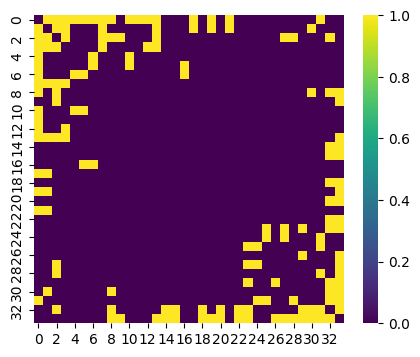

torch.Size([1, 34, 34])


In [37]:
from torch_geometric.utils import to_dense_adj 
print(f'edge_index = {data.edge_index.shape}')
adj = to_dense_adj(data.edge_index)

plt.figure(figsize=(5, 4))
sns.heatmap(adj.squeeze(0), cmap="viridis", vmin=0, vmax=1)
plt.show()
print(adj.shape)

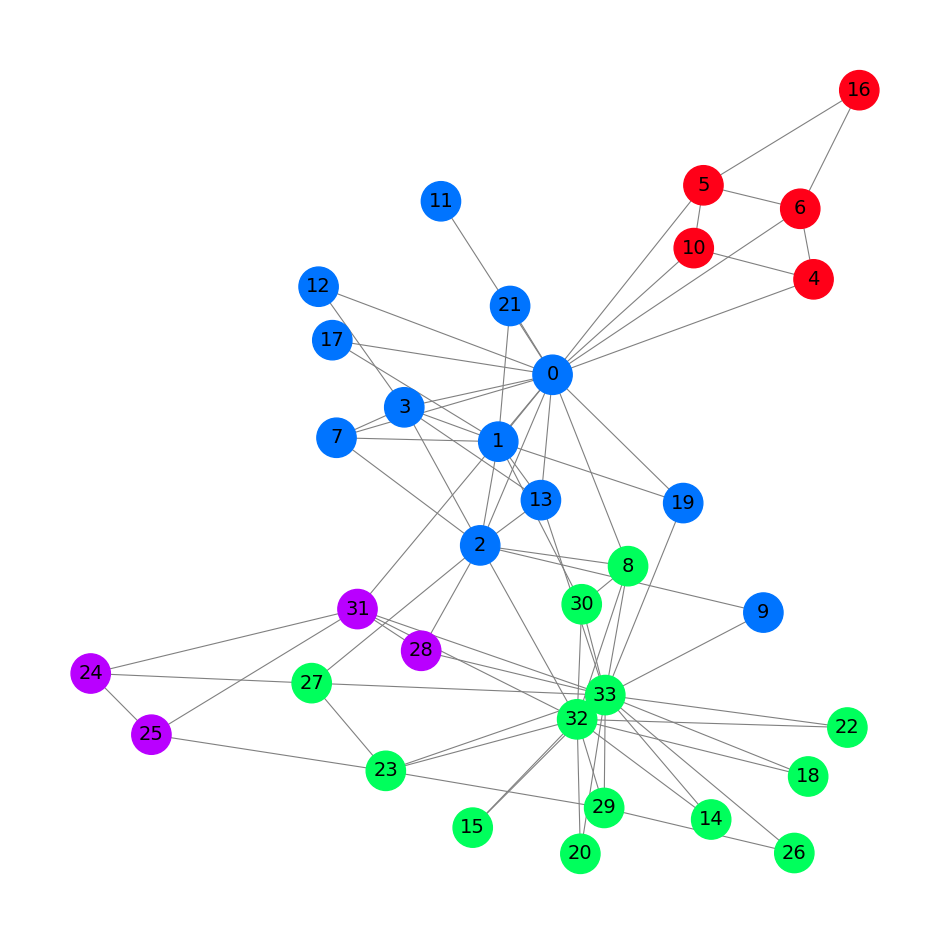

In [38]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=True,
                node_size=800,
                node_color=data.y,
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.8,
                edge_color="grey",
                font_size=14
                )
plt.show()

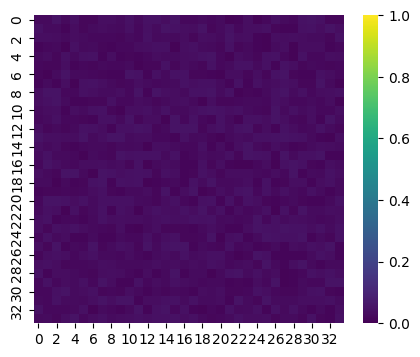

DenseGCN(
  (gcn1): DenseGCNConv(34, 64)
  (gcn2): DenseGCNConv(64, 4)
)
Camada: adj_param
Tamanho (Shape): torch.Size([1, 34, 34])
Valores:
Parameter containing:
tensor([[[0.0246, 0.0266, 0.0493,  ..., 0.0416, 0.0191, 0.0166],
         [0.0466, 0.0282, 0.0309,  ..., 0.0334, 0.0469, 0.0375],
         [0.0359, 0.0372, 0.0338,  ..., 0.0284, 0.0162, 0.0440],
         ...,
         [0.0246, 0.0232, 0.0464,  ..., 0.0363, 0.0421, 0.0288],
         [0.0441, 0.0200, 0.0217,  ..., 0.0295, 0.0126, 0.0388],
         [0.0270, 0.0285, 0.0159,  ..., 0.0166, 0.0144, 0.0412]]],
       requires_grad=True)

Camada: gcn1.bias
Tamanho (Shape): torch.Size([64])
Valores:
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

Camada: gcn

In [70]:
from torch_geometric.nn import DenseGCNConv
from torch.nn import Linear
import torch.nn as nn
import torch.nn.functional as F

class DenseGCN(torch.nn.Module):
    def __init__(self, adj):
        super().__init__()
        
        self.adj_param = nn.Parameter(adj.clone().float())

        self.gcn1 = DenseGCNConv(34, 64) 
        self.gcn2 = DenseGCNConv(64, 4)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)
    
    def forward(self, x):
        # adj_positive = F.sigmoid(self.adj_param)
        adj_positive = F.sigmoid(50 * self.adj_param) # F.softmax(self.adj_param, dim=-1)
        # adj_positive = gumbel_sigmoid(self.adj_param)
        
        adj_norm = self.normalize_adj(adj_positive)
        
        x = self.gcn1(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.gcn2(x, adj_norm, add_loop=False)
        
        return x


adj = torch.rand((34,34)) * 0.04 + 0.01
plt.figure(figsize=(5, 4))
sns.heatmap(adj, cmap="viridis", vmin=0, vmax=1)
plt.show()
adj = adj.unsqueeze(0)  
model = DenseGCN(adj)
print(model)
for name, param in model.named_parameters():
    print(f"Camada: {name}")
    print(f"Tamanho (Shape): {param.shape}")
    print(f"Valores:\n{param}\n")

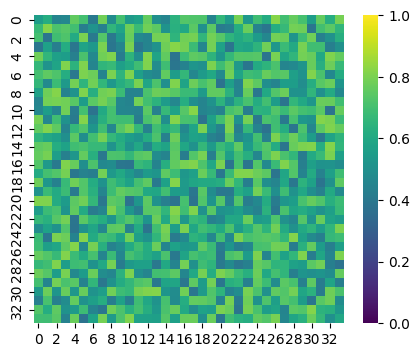

Epoch   0 | Loss: 1.58 | Acc: 11.76%


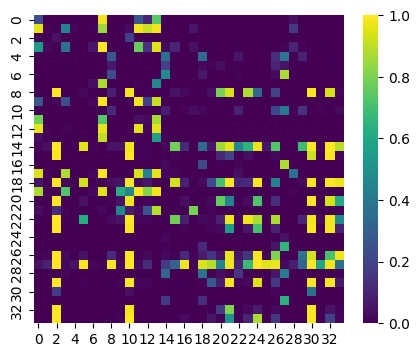

Epoch  10 | Loss: 0.88 | Acc: 70.59%


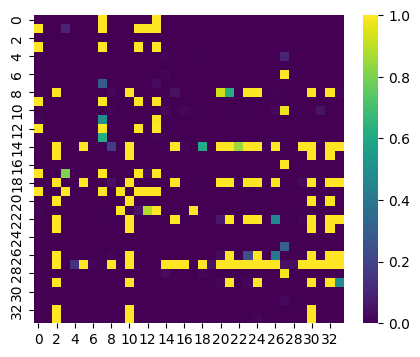

Epoch  20 | Loss: 0.34 | Acc: 91.18%
Perfect accuracy reached at epoch 24. Stopping training.


In [74]:
adj = torch.rand((34,34)) * 0.04 + 0.01
adj = adj.unsqueeze(0)
model = DenseGCN(adj)
x_dense = data.x.unsqueeze(0)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []

# Training loop
for epoch in range(401):
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    z = model(x_dense)
    z = z.squeeze(0)
    # Calculate loss function
    loss = criterion(z, data.y) + F.sigmoid(50 * model.adj_param).sum() * 0.0002  # Regularization term

    # Calculate accuracy
    acc = accuracy(z.argmax(dim=1), data.y)

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    losses.append(loss)
    accuracies.append(acc)
    outputs.append(z.argmax(dim=1))

    # Print metrics every 10 epochs
    if epoch % 10 == 0:
        adj_now = torch.sigmoid(50* model.adj_param).detach().cpu().numpy()
        
        plt.figure(figsize=(5, 4))
        sns.heatmap(adj_now.squeeze(0), cmap="viridis", vmin=0, vmax=1)
        plt.show()
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%')
    if acc == 1.0:
        print(f'Perfect accuracy reached at epoch {epoch}. Stopping training.')
        break

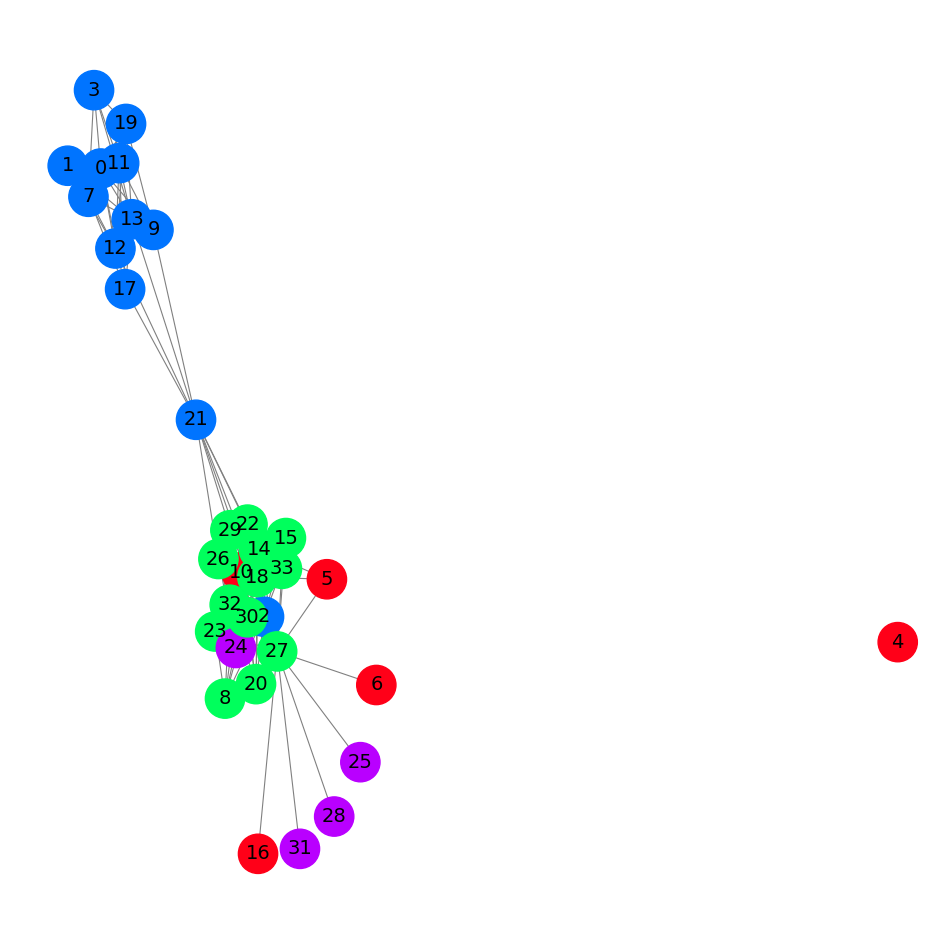

In [ ]:
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data 
from torch_geometric.utils import to_networkx
import torch
adj = F.sigmoid(50*model.adj_param).detach().squeeze(0).numpy()

adj = np.where(adj > 0.6,1, 0)

edge_index, edge_weight = dense_to_sparse(torch.from_numpy(adj))
data_view = Data(edge_index=edge_index,num_nodes=34)


G = to_networkx(data_view, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=True,
                node_size=800,
                node_color=data.y,
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.8,
                edge_color="grey",
                font_size=14
                )
plt.show()

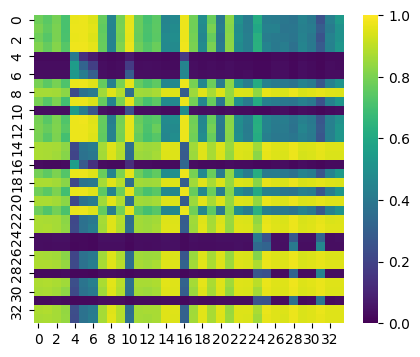

In [17]:
adj_real = F.sigmoid(model.adj_param).detach().cpu().numpy()
plt.figure(figsize=(5, 4))
sns.heatmap(adj_real.squeeze(0), cmap="viridis", vmin=0, vmax=1)
plt.show()

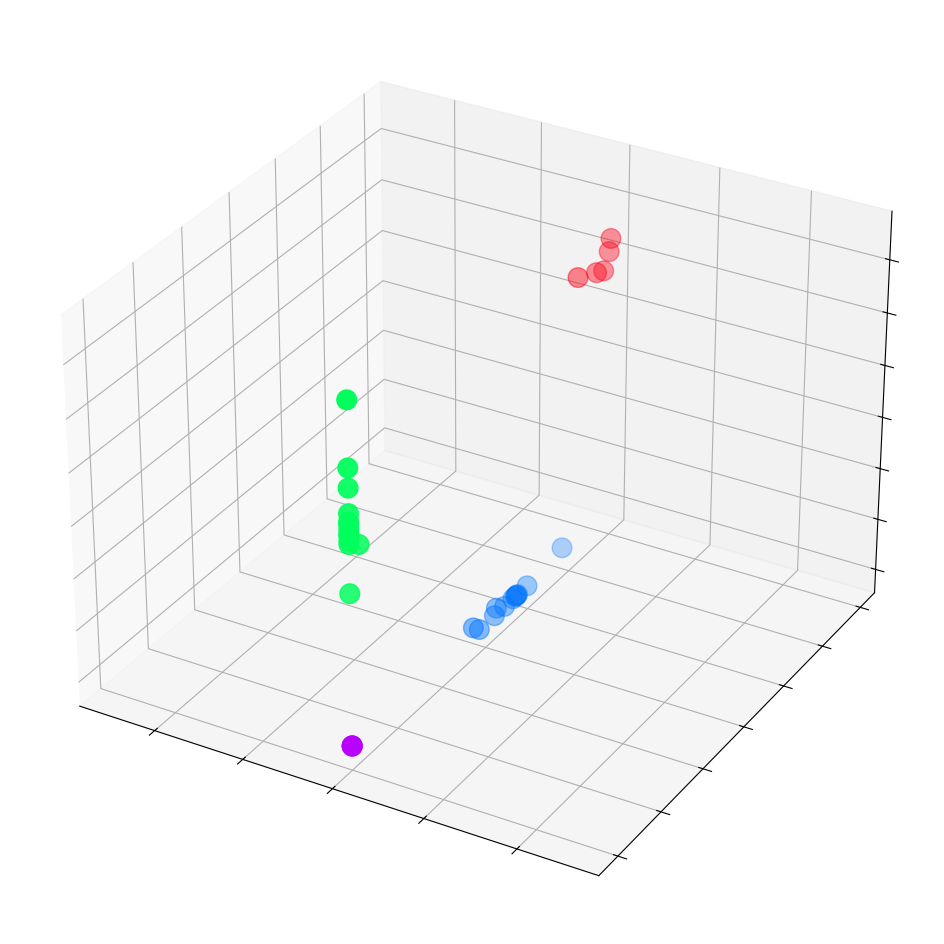

In [16]:
# Get first embedding at epoch = 0
embed = h.detach().cpu().numpy()

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.patch.set_alpha(0)
plt.tick_params(left=False,
                bottom=False,
                labelleft=False,
                labelbottom=False)
ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2],
           s=200, c=data.y, cmap="hsv", vmin=-2, vmax=3)

plt.show()

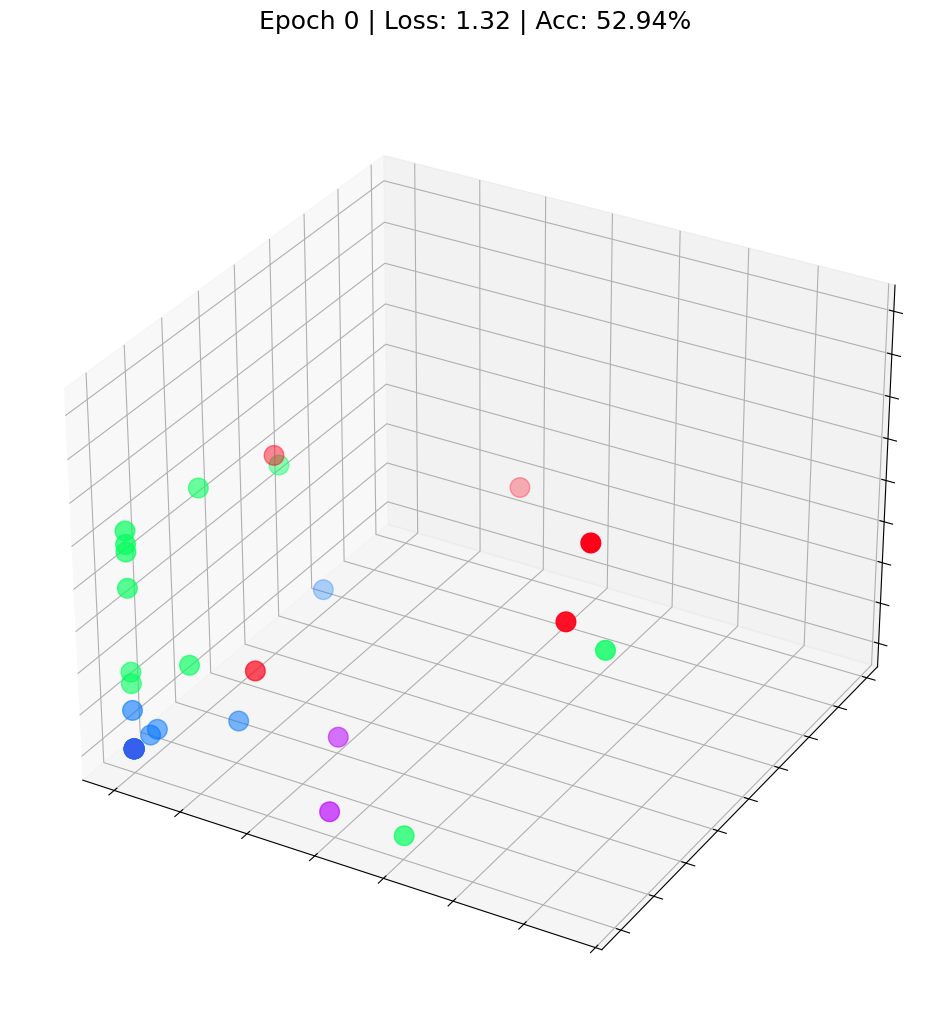

In [17]:
def animate(i):
    embed = embeddings[i].detach().cpu().numpy()
    ax.clear()
    ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2],
           s=200, c=data.y, cmap="hsv", vmin=-2, vmax=3)
    plt.title(f'Epoch {i} | Loss: {losses[i]:.2f} | Acc: {accuracies[i]*100:.2f}%',
              fontsize=18, pad=40)

fig = plt.figure(figsize=(12, 12))
plt.axis('off')
ax = fig.add_subplot(projection='3d')
plt.tick_params(left=False,
                bottom=False,
                labelleft=False,
                labelbottom=False)

anim = animation.FuncAnimation(fig, animate, \
              np.arange(0, 200, 10), interval=800, repeat=True)
html = HTML(anim.to_html5_video())

display(html)